# Découverte des données

### L'objectif de cette annalyse est de savoir durant quel mois nous avons realisé le meilleur chiffre d'affaire ? 
### Quel magasin a obtenu le plus de commande ? 
### En quel moment doit on faire une campagne publicitaire  pour avoir le plus de vente ? 
### Quel produit se vend le plus ?

In [1]:
# importer les packages
import os
import pandas as pd # pour la visualisation des données
import matplotlib.pyplot as plt
import seaborn as sns

## Créer une liste des fichiers

In [2]:
files = [file for file in os.listdir(r"C:\Users\kapni\Downloads\data-sales-main (1)\data-sales-main")]
for file in files:
    print(file)

Sales_April_2019.csv
Sales_August_2019.csv
Sales_December_2019.csv
Sales_February_2019.csv
Sales_January_2019.csv
Sales_July_2019.csv
Sales_June_2019.csv
Sales_March_2019.csv
Sales_May_2019.csv
Sales_November_2019.csv
Sales_October_2019.csv
Sales_September_2019.csv


### on regroupe tout ces fichiers dans un seul fichier

In [3]:
# on commence par creer un chemin
path=r"C:\Users\kapni\Downloads\data-sales-main (1)\data-sales-main"
# on cree une base de donnée
all_data = pd.DataFrame()

for file in files:
        current_data = pd.read_csv(path+'/'+file)
        all_data = pd.concat([all_data, current_data])
        print(all_data)
        

      Order ID                     Product Quantity Ordered Price Each  \
0       176558        USB-C Charging Cable                2      11.95   
1          NaN                         NaN              NaN        NaN   
2       176559  Bose SoundSport Headphones                1      99.99   
3       176560                Google Phone                1        600   
4       176560            Wired Headphones                1      11.99   
...        ...                         ...              ...        ...   
18378   194090                Google Phone                1        600   
18379   194091       AA Batteries (4-pack)                1       3.84   
18380   194092      AAA Batteries (4-pack)                2       2.99   
18381   194093       AA Batteries (4-pack)                1       3.84   
18382   194094    Lightning Charging Cable                1      14.95   

           Order Date                        Purchase Address  
0      04/19/19 08:46            917 1st St, Da

### verifions les donnée de janvier

In [4]:
data_janvier =pd.read_csv(path+"/Sales_January_2019.csv")
print(data_janvier)

     Order ID                   Product Quantity Ordered Price Each  \
0      141234                    iPhone                1        700   
1      141235  Lightning Charging Cable                1      14.95   
2      141236          Wired Headphones                2      11.99   
3      141237          27in FHD Monitor                1     149.99   
4      141238          Wired Headphones                1      11.99   
...       ...                       ...              ...        ...   
9718   150497              20in Monitor                1     109.99   
9719   150498          27in FHD Monitor                1     149.99   
9720   150499           ThinkPad Laptop                1     999.99   
9721   150500    AAA Batteries (4-pack)                2       2.99   
9722   150501              Google Phone                1        600   

          Order Date                       Purchase Address  
0     01/22/19 21:25        944 Walnut St, Boston, MA 02215  
1     01/28/19 14:15   

# ## convertissons notre base de données en une seule grande base de données

In [5]:
all_data.to_csv(path+'/all_data.csv', index = False)

In [6]:
all_data.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

In [7]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


# ## on va voir les valeurs manquantes 


In [8]:
all_data.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [9]:
# etant donnée qu'on a plus de 16000 VALEUR DANS notre data, on va donc faire le choix de supprimer nos isnull
all_data = all_data.dropna(how="all")
all_data.shape

(186305, 6)

## Quel est le mois durant lequel nous avons réalisé le meiller chiffre d'affaire ?

In [10]:
# on va commencer par extraire les mois
# pour ce faire nous allons definir une fonction qui va extraire les mois
def month(x): # on cree notre fonction lamda
    return x.split('/')[0] # car ici l'année est une convention americaine et la data comment par le moi 

In [11]:
# on cree une nouvelle colonne month pour faciliter notre travail
all_data["month"]=all_data['Order Date'].apply(month)
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",04
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",04
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",04
...,...,...,...,...,...,...,...
11681,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001",09
11682,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016",09
11683,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016",09
11684,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016",09


In [12]:
# on verifie nos mois
all_data['month'].unique()

array(['04', '05', 'Order Date', '08', '09', '12', '01', '02', '03', '07',
       '06', '11', '10'], dtype=object)

In [13]:
# on remarque qu'on a une valeur notée "Order Date"
# on va appliquer un filtre pour ne garder que les valeur souhaité, soit des number
all_data=all_data[all_data["month"]!="Order Date"]
all_data['month'].unique()

array(['04', '05', '08', '09', '12', '01', '02', '03', '07', '06', '11',
       '10'], dtype=object)

In [14]:
#verification du type
all_data.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
month               object
dtype: object

In [15]:
# on change le type de mois en un entier affin d'effectuer nos manipulations
all_data["month"]=all_data["month"].astype(int)

C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\1981791196.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data["month"]=all_data["month"].astype(int)


In [16]:
# verification
all_data.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
month                int32
dtype: object

# trouvons le chiffre d'affaire

In [17]:
#Pour se faire, nous devons egalement transformer la quantité de commande et le prix en entier et en float( entier avec virgule)
all_data["Quantity Ordered"]=all_data["Quantity Ordered"].astype(int)
all_data["Price Each"]=all_data["Price Each"].astype(float)
all_data.dtypes

C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\3986489185.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data["Quantity Ordered"]=all_data["Quantity Ordered"].astype(int)
C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\3986489185.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data["Price Each"]=all_data["Price Each"].astype(float)


Order ID             object
Product              object
Quantity Ordered      int32
Price Each          float64
Order Date           object
Purchase Address     object
month                 int32
dtype: object

In [18]:
# creons maintenant le chiffre d'affaire
print(all_data.columns.tolist())

['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'month']


In [19]:
# on supprime tous les espaces inutiles qui pourrait corrompre les noms de nos colonnes
all_data.columns = all_data.columns.str.strip()

In [20]:
print(all_data.columns.tolist())

['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'month']


In [21]:
all_data.columns = all_data.columns.str.strip()

In [22]:
all_data["sales"]=all_data["Price Each"]*all_data["Quantity Ordered"]
all_data.head()

C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\2578360459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data["sales"]=all_data["Price Each"]*all_data["Quantity Ordered"]


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


In [23]:
# on regroupe les mois et on fais la somme de ces mois
monthly_revenue=all_data.groupby("month")["sales"].sum()
monthly_revenue

month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: sales, dtype: float64

### on va faire une visualisation de nos données avec matplotlip


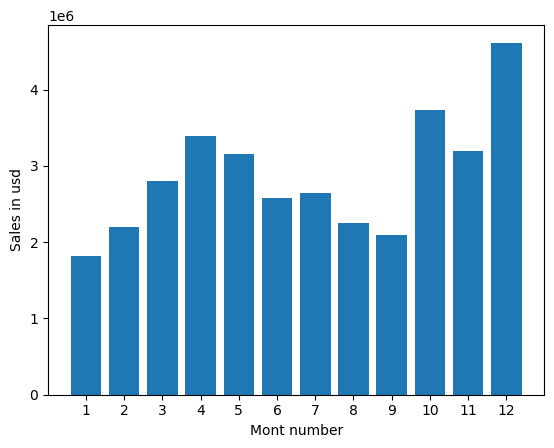

In [24]:
months=range(1,13)
plt.bar(months,all_data.groupby("month")["sales"].sum())
plt.xticks(months)
plt.ylabel("Sales in usd")
plt.xlabel('Mont number')
plt.show()

## Dans quelle ville avons nous enregistré le maximum de commande ?

In [25]:
# on commence par extraire le nom de la ville dans l'adresse
# pour se faire on va utiliser la methode split ET UNE FONCTION LAMDA
def city(x):
    return x.split(',')[1]


In [26]:
all_data['city']=all_data['Purchase Address'].apply(city)
all_data

C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\2992180682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data['city']=all_data['Purchase Address'].apply(city)


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,city
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles
...,...,...,...,...,...,...,...,...,...
11681,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001",9,8.97,Los Angeles
11682,259354,iPhone,1,700.00,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016",9,700.00,San Francisco
11683,259355,iPhone,1,700.00,09/23/19 07:39,"220 12th St, San Francisco, CA 94016",9,700.00,San Francisco
11684,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016",9,379.99,San Francisco


In [27]:
# on regroupe nos ville en fonction des commandes
all_data.groupby('city')['city'].count()

city
 Atlanta          14881
 Austin            9905
 Boston           19934
 Dallas           14820
 Los Angeles      29605
 New York City    24876
 Portland         12465
 San Francisco    44732
 Seattle          14732
Name: city, dtype: int64

In [28]:
# on s'appercoit que cette donné nous donne a la fois l'index et la valeur or nous avons juste
all_data.groupby('city')['city'].count().index

Index([' Atlanta', ' Austin', ' Boston', ' Dallas', ' Los Angeles',
       ' New York City', ' Portland', ' San Francisco', ' Seattle'],
      dtype='object', name='city')

In [29]:
all_data.groupby('city')['city'].count().values

array([14881,  9905, 19934, 14820, 29605, 24876, 12465, 44732, 14732],
      dtype=int64)

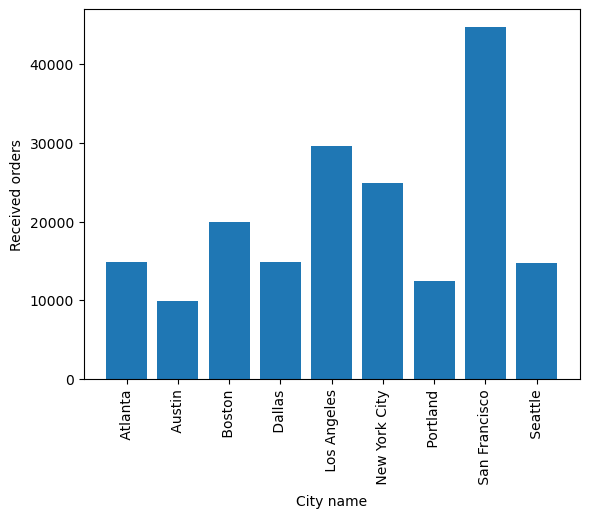

In [30]:
#affichons nos données
data_city= all_data.groupby('city')['city'].count()
plt.bar(data_city.index,data_city.values)
plt.xticks(rotation = 'vertical') # parce que je veux que la rotation de mon texte soit verticale
plt.ylabel("Received orders")
plt.xlabel('City name')
plt.show()

### On peut donc aisement grâce à ce graphe affirmer que la ville qui a le plus de commandes c'est San Francisco suivie de Los Angeles. Et celles ayant le moins de commandes sont la ville de Austin suivie de Portland

# 2ème question: Quand est ce qu'on peut mener une compagne publicitaire pour avoir plus de vente ?

In [31]:
# pour repondre a cette question, nous allons extraire l'heure de notre base de donné et par la suite nous allons étudier 
# le nombre de commandes passées a chaque heure. grace a cette donnée, nous allons ensuite tracer une courbe qui montre
# l'evolution des commandes
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,city
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles


In [32]:
# on peut donc constater que dans la colonne Order Date nous avons la date et l'heure de la commande.
# je vais donc créer une colonne hour
# pour se faire je vais donc créer une fonction qui va extraire une donnée temporaire
all_data["hour"]=pd.to_datetime(all_data["Order Date"]).dt.hour

C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\4033815943.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data["hour"]=pd.to_datetime(all_data["Order Date"]).dt.hour


In [33]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,city,hour
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,8
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,22
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,14
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles,9


In [34]:
# Compte le nombre de lignes (commandes) par heure
sales_by_hour = all_data.groupby('hour').count()['Order ID']

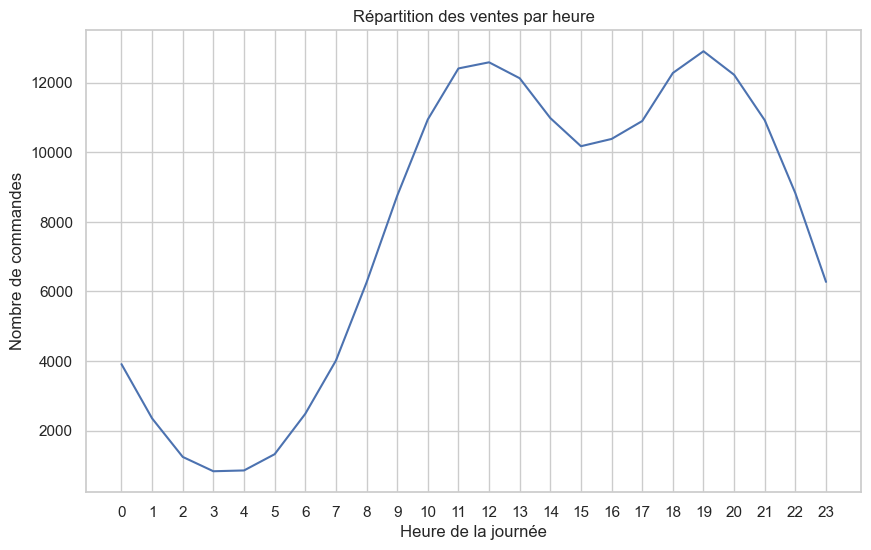

In [35]:


# Configuration du style
sns.set_theme(style="whitegrid")

# Création du graphique
hours = [hour for hour, df in all_data.groupby('hour')]

plt.figure(figsize=(10, 6))
sns.lineplot(x=hours, y=sales_by_hour)
plt.xticks(hours) # Affiche toutes les heures de 0 à 23
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre de commandes')
plt.title('Répartition des ventes par heure')
plt.show()


## d'apres notre graphe on constate que les pics de commandes sont entre 12H et 19H. c'est donc l'heure parfait pour passer notre publicité

C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\1003859231.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], errors='coerce')
C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\1003859231.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_data['Day_Name'] = all_data['Order Date'].dt.day_name()
C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\1003859231.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum i

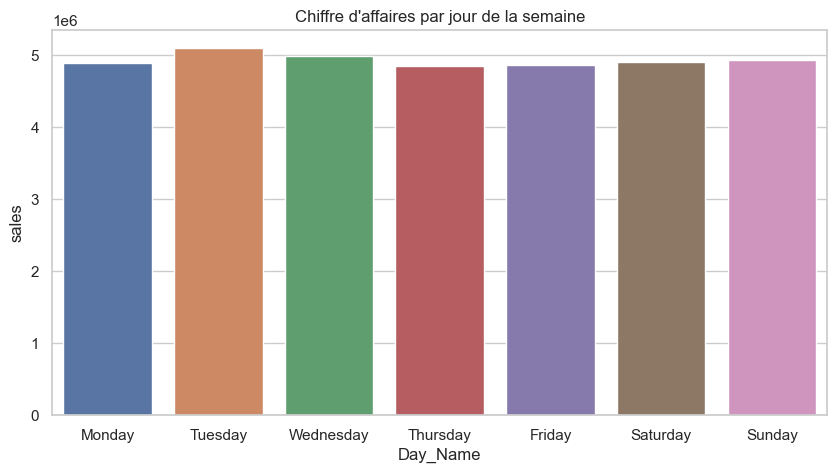

In [36]:
# on peut pousser notre analyse plus loin pour voir les jour de la semaine qui enregistre le plus de vente

# 1. Conversion forcée en datetime (essentiel !)
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], errors='coerce')

# 1. Extraction
all_data['Day_Name'] = all_data['Order Date'].dt.day_name()

# 2. Groupe par jour et somme des ventes
sales_by_day = all_data.groupby('Day_Name').sum()['sales'].reset_index()

# 3. Visualisation avec Seaborn
plt.figure(figsize=(10,5))
sns.barplot(x='Day_Name', y='sales', data=sales_by_day, 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Chiffre d\'affaires par jour de la semaine')
plt.show()


# 3 Quel produit realise le plus de vente ?

In [37]:
# pour repondre a cette question, nous allors regroupper le chiffre d'affaire de chaque produit
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,city,hour,Day_Name
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,8,Friday
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,22,Sunday
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14,Friday
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,14,Friday
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles,9,Tuesday


<Axes: xlabel='Product'>

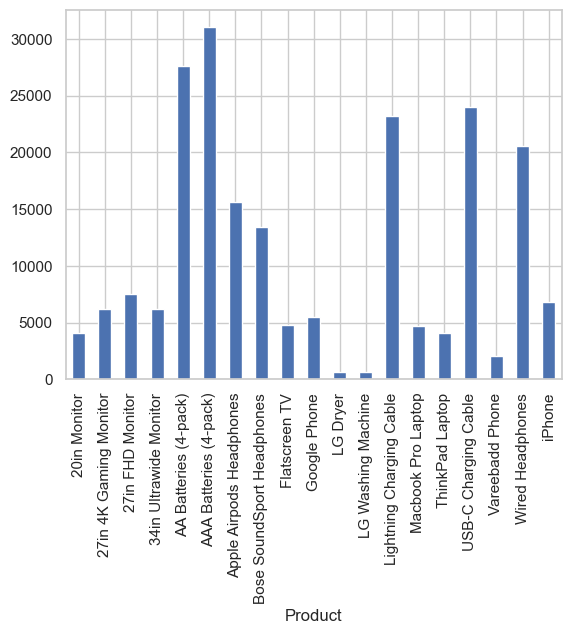

In [38]:
# on commence par groupper les produits et ensuite on fait la somme de chaque produit vendu; en fin on trace notre graphique
# avec la methode plot(kind='bar')
all_data.groupby("Product")["Quantity Ordered"].sum().plot(kind='bar')

### on constate donc que le produit le plus vendu sont les batteries AAA, AA, suivi des cables de chargeur

# Annalysons le lien entre le prix et les ventes 

In [39]:
# pour se faire, nous allons supperposer deux diagrmmes. 
price_mean=all_data.groupby("Product")["Price Each"].mean()
price_mean

Product
20in Monitor                   109.99
27in 4K Gaming Monitor         389.99
27in FHD Monitor               149.99
34in Ultrawide Monitor         379.99
AA Batteries (4-pack)            3.84
AAA Batteries (4-pack)           2.99
Apple Airpods Headphones       150.00
Bose SoundSport Headphones      99.99
Flatscreen TV                  300.00
Google Phone                   600.00
LG Dryer                       600.00
LG Washing Machine             600.00
Lightning Charging Cable        14.95
Macbook Pro Laptop            1700.00
ThinkPad Laptop                999.99
USB-C Charging Cable            11.95
Vareebadd Phone                400.00
Wired Headphones                11.99
iPhone                         700.00
Name: Price Each, dtype: float64

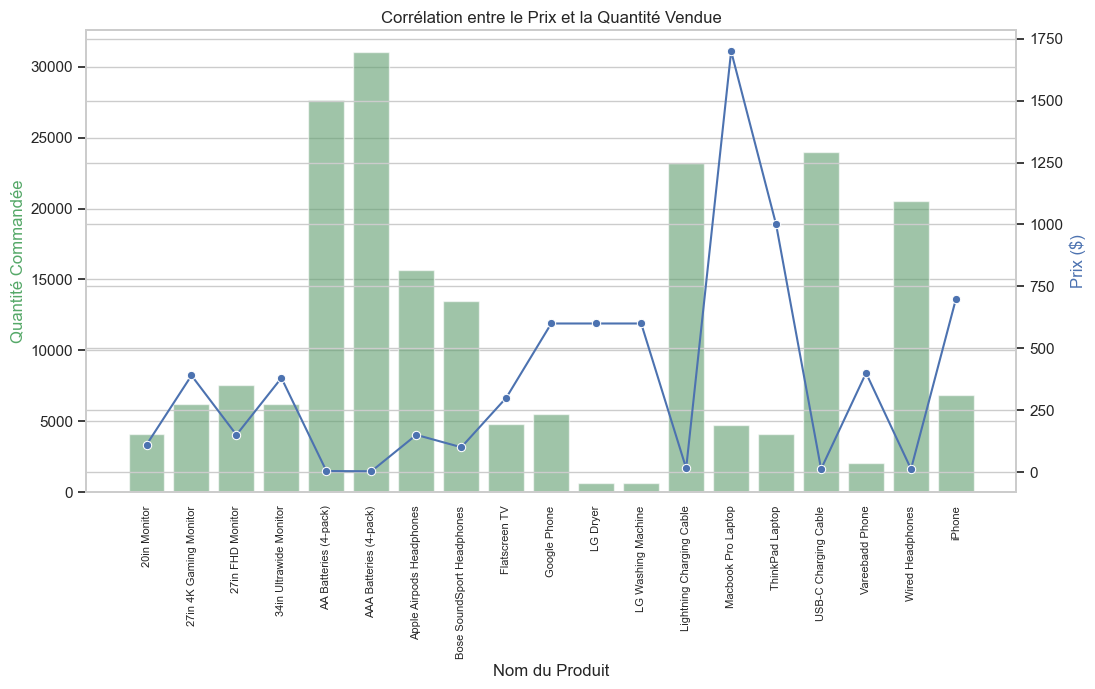

In [40]:
# 1. Préparation des données
# On récupère la somme des quantités par produit
prices = all_data.groupby('Product')['Price Each'].mean() # Prix moyen par produit
quantity_ordered = all_data.groupby('Product')['Quantity Ordered'].sum()
products = [product for product, df in all_data.groupby('Product')]

# 2. Création du graphique avec un double axe Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Premier axe (Y1) : Barres pour la quantité
ax2 = ax1.twinx() # Crée un deuxième axe partagé avec le premier
sns.barplot(x=products, y=quantity_ordered, ax=ax1, color='g', alpha=0.6)
sns.lineplot(x=products, y=prices, ax=ax2, color='b', marker='o')

# 3. Personnalisation
ax1.set_xlabel('Nom du Produit')
ax1.set_ylabel('Quantité Commandée', color='g')
ax2.set_ylabel('Prix ($)', color='b')
ax1.set_xticklabels(products, rotation='vertical', size=8)

plt.title('Corrélation entre le Prix et la Quantité Vendue')
plt.show()


## Quelles sont les combinaisons de produits les plus vendu ?

In [41]:
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,city,hour,Day_Name
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,8,Friday
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,22,Sunday
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14,Friday
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,14,Friday
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles,9,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
11681,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",9,8.97,Los Angeles,20,Tuesday
11682,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",9,700.00,San Francisco,16,Sunday
11683,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",9,700.00,San Francisco,7,Monday
11684,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",9,379.99,San Francisco,17,Thursday


In [42]:
df=all_data[all_data["Order ID"].duplicated(keep=False)]

In [43]:
# on va groupper les produit ayant le même numero de commande
df['Grouped']=df.groupby('Order ID')["Product"].transform(lambda x: ','.join(x))

C:\Users\kapni\AppData\Local\Temp\ipykernel_128052\1279344897.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grouped']=df.groupby('Order ID')["Product"].transform(lambda x: ','.join(x))


In [44]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,city,hour,Day_Name,Grouped
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14,Friday,"Google Phone,Wired Headphones"
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,14,Friday,"Google Phone,Wired Headphones"
18,176574,Google Phone,1,600.00,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles,19,Wednesday,"Google Phone,USB-C Charging Cable"
19,176574,USB-C Charging Cable,1,11.95,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,11.95,Los Angeles,19,Wednesday,"Google Phone,USB-C Charging Cable"
30,176585,Bose SoundSport Headphones,1,99.99,2019-04-07 11:31:00,"823 Highland St, Boston, MA 02215",4,99.99,Boston,11,Sunday,"Bose SoundSport Headphones,Bose SoundSport Hea..."
...,...,...,...,...,...,...,...,...,...,...,...,...
11628,259303,AA Batteries (4-pack),1,3.84,2019-09-20 20:18:00,"106 7th St, Atlanta, GA 30301",9,3.84,Atlanta,20,Friday,"34in Ultrawide Monitor,AA Batteries (4-pack)"
11639,259314,Wired Headphones,1,11.99,2019-09-16 00:25:00,"241 Highland St, Atlanta, GA 30301",9,11.99,Atlanta,0,Monday,"Wired Headphones,AAA Batteries (4-pack)"
11640,259314,AAA Batteries (4-pack),2,2.99,2019-09-16 00:25:00,"241 Highland St, Atlanta, GA 30301",9,5.98,Atlanta,0,Monday,"Wired Headphones,AAA Batteries (4-pack)"
11677,259350,Google Phone,1,600.00,2019-09-30 13:49:00,"519 Maple St, San Francisco, CA 94016",9,600.00,San Francisco,13,Monday,"Google Phone,USB-C Charging Cable"


In [49]:
# les elements dupliqué je n'en aurai plus besoin. je vais donc garder un seul order id pour les élément groupé
df2= df.drop_duplicates(subset=["Order ID"])
df2

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,city,hour,Day_Name,Grouped
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14,Friday,"Google Phone,Wired Headphones"
18,176574,Google Phone,1,600.00,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles,19,Wednesday,"Google Phone,USB-C Charging Cable"
30,176585,Bose SoundSport Headphones,1,99.99,2019-04-07 11:31:00,"823 Highland St, Boston, MA 02215",4,99.99,Boston,11,Sunday,"Bose SoundSport Headphones,Bose SoundSport Hea..."
32,176586,AAA Batteries (4-pack),2,2.99,2019-04-10 17:00:00,"365 Center St, San Francisco, CA 94016",4,5.98,San Francisco,17,Wednesday,"AAA Batteries (4-pack),Google Phone"
119,176672,Lightning Charging Cable,1,14.95,2019-04-12 11:07:00,"778 Maple St, New York City, NY 10001",4,14.95,New York City,11,Friday,"Lightning Charging Cable,USB-C Charging Cable"
...,...,...,...,...,...,...,...,...,...,...,...,...
11617,259296,Apple Airpods Headphones,1,150.00,2019-09-28 16:48:00,"894 6th St, Dallas, TX 75001",9,150.00,Dallas,16,Saturday,"Apple Airpods Headphones,Apple Airpods Headphones"
11619,259297,iPhone,1,700.00,2019-09-15 18:54:00,"138 Main St, Boston, MA 02215",9,700.00,Boston,18,Sunday,"iPhone,Lightning Charging Cable,Lightning Char..."
11627,259303,34in Ultrawide Monitor,1,379.99,2019-09-20 20:18:00,"106 7th St, Atlanta, GA 30301",9,379.99,Atlanta,20,Friday,"34in Ultrawide Monitor,AA Batteries (4-pack)"
11639,259314,Wired Headphones,1,11.99,2019-09-16 00:25:00,"241 Highland St, Atlanta, GA 30301",9,11.99,Atlanta,0,Monday,"Wired Headphones,AAA Batteries (4-pack)"


In [50]:
df['Grouped'].value_counts()[0:5]

iPhone,Lightning Charging Cable         1764
Google Phone,USB-C Charging Cable       1712
iPhone,Wired Headphones                  722
Vareebadd Phone,USB-C Charging Cable     624
Google Phone,Wired Headphones            606
Name: Grouped, dtype: int64

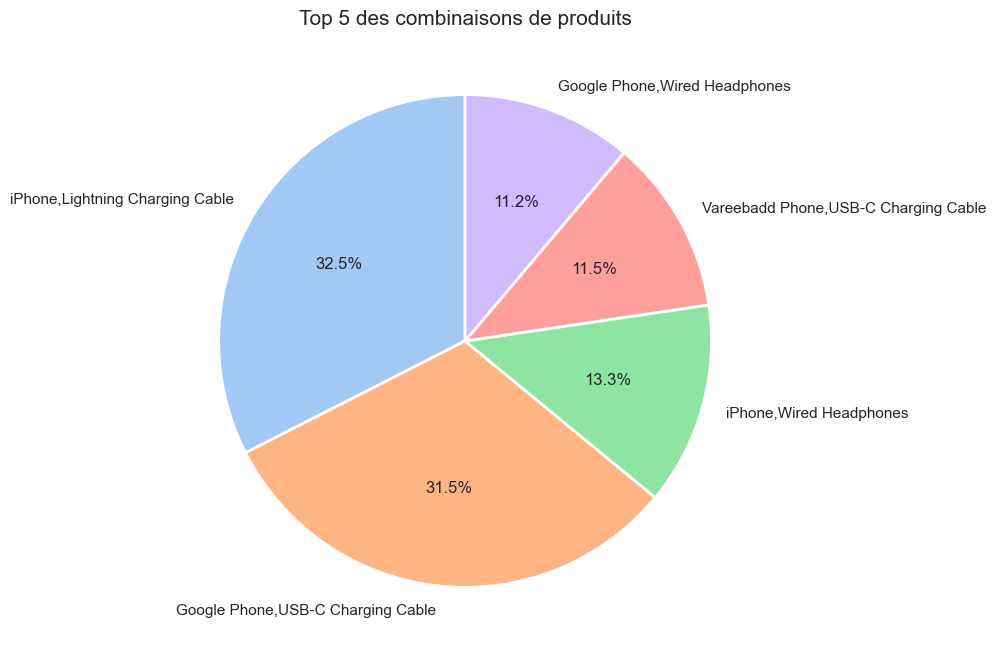

In [60]:
# j'affiche en suite le resultat obtenu dans un diagramme en camemberg ou pie chart
# 1. On définit une palette de couleurs moderne
colors = sns.color_palette('pastel')

df['Grouped'].value_counts()[0:5].plot.pie(
    figsize=(8, 8),
    autopct='%1.1f%%',      # Affiche les pourcentages
    colors=colors,          # Applique les belles couleurs
    startangle=90,          # Commence le dessin à la verticale
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Sépare les tranches
)
plt.title("Top 5 des combinaisons de produits", fontsize=15)
plt.ylabel("") # Supprime le texte 'Grouped' moche sur le côté
plt.show()

In [1]:
import os
print(os.getcwd())


C:\Users\kapni
